In [1]:
import os, sys, time
from functools import partial

import numpy as np
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

from pyscf import gto, scf, ao2mo, fci

# afqmc's config turns on float64 in jax and selects the CPU/GPU backend.
# It must be called before any heavy jax work.
from afqmc import config as afqmc_config
afqmc_config.setup_jax()

import jax
import jax.numpy as jnp
from jax import jit, random

from afqmc import prep, propagation, sampling, fp_sampling, linalg_utils
from afqmc.wavefunctions import wavefunctions_unrestricted as uwf

# trot is not installed as a package in this environment; add it to the path
TROT_PATH = "/home/sharmagroup/sharmagroup/trot_lab/trot"
if TROT_PATH not in sys.path:
    sys.path.insert(0, TROT_PATH)

np.set_printoptions(precision=8, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
print("jax devices:", jax.devices())

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-30-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu
jax devices: [CudaDevice(id=0)]


In [2]:
def hubbard_h1(n_sites, t, pbc=False):
    "Nearest-neighbour hopping matrix of an open (or periodic) chain."
    h1 = np.zeros((n_sites, n_sites))
    for i in range(n_sites - 1):
        h1[i, i + 1] = h1[i + 1, i] = -t
    if pbc and n_sites > 2:
        h1[0, -1] = h1[-1, 0] = -t
    return h1

def hubbard_eri(n_sites, u):
    "On-site two-electron integrals (ii|ii) = U in chemist notation."
    eri = np.zeros((n_sites,) * 4)
    for i in range(n_sites):
        eri[i, i, i, i] = u
    return eri

In [3]:
T_HOP  = 1.0     # hopping t
U_INT  = 4.0     # on-site repulsion U
N_SITES = 2

h1_dimer = hubbard_h1(N_SITES, T_HOP, pbc=True)
evals, evecs = np.linalg.eigh(h1_dimer)
evecs = evecs * np.sign(evecs[0])          # fix an arbitrary overall sign for display
print("hopping matrix h1 =\n", h1_dimer)
print("\none-particle levels :", evals)
print(f"bonding orbital = {evecs[:, 0]}")
print(f"exact (mf) ground-state energy of 1 electron on {N_SITES} sites  E0 = {evals[0]:.8f}")

hopping matrix h1 =
 [[ 0. -1.]
 [-1.  0.]]

one-particle levels : [-1.  1.]
bonding orbital = [0.70710678 0.70710678]
exact (mf) ground-state energy of 1 electron on 2 sites  E0 = -1.00000000


In [4]:
def hubbard_mf(n_sites, t, u, nelec, dm0=None, pbc=False):
    """
    Build a PySCF UHF object for a Hubbard chain.

    Returns (h1, eri, mol, mf).  `nelec` is (n_alpha, n_beta).
    """
    h1  = hubbard_h1(n_sites, t, pbc)
    eri = hubbard_eri(n_sites, u)

    mol = gto.M()
    mol.nelectron     = sum(nelec)
    mol.nao           = n_sites
    mol.spin          = nelec[0] - nelec[1]     # n_alpha - n_beta
    mol.incore_anyway = True
    mol.verbose       = 4
    mol.build()

    mf = scf.UHF(mol)
    mf.get_hcore = lambda *args: h1              # kinetic + external -> hopping
    mf.get_ovlp  = lambda *args: np.eye(n_sites) # sites are orthonormal
    mf._eri      = ao2mo.restore(8, eri, n_sites)
    mf.conv_tol  = 1e-12
    mf.max_cycle = 200
    mf.verbose   = 4
    mf.kernel(dm0=dm0)
    return h1, eri, mol, mf

In [5]:
# ---- one electron on two sites -------------------------------------------------
NELEC_A = (1, 0)                      # fully spin polarised: 1 alpha electron

dm0 = np.zeros((2, N_SITES, N_SITES)) # break the site symmetry to help SCF start
dm0[0, 0, 0] = 1.0

h1_A, eri_A, mol_A, mf_A = hubbard_mf(N_SITES, T_HOP, U_INT, NELEC_A, dm0=dm0)

print("E(UHF)   = %.12f" % mf_A.e_tot)
print("E(exact) = %.12f" % (-T_HOP))
print("error    = %.2e" % abs(mf_A.e_tot + T_HOP))
print("\nalpha MO coefficients (columns = orbitals, rows = sites):\n", mf_A.mo_coeff[0])
print("alpha occupations:", mf_A.mo_occ[0])



******** 1 electron system ********

WARN: HOMO -1 >= LUMO -1

converged SCF energy = -1  <S^2> = 0.75  2S+1 = 2
E(UHF)   = -1.000000000000
E(exact) = -1.000000000000
error    = 0.00e+00

alpha MO coefficients (columns = orbitals, rows = sites):
 [[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]
alpha occupations: [1. 0.]


In [38]:
mf_A.mo_coeff[0]

array([[ 0.70710678,  0.70710678],
       [ 0.70710678, -0.70710678]])

In [6]:
def spin_chol(n_sites, u):
    """
    Spin (Hirsch) decomposition:  L^g_up = -i sqrt(U) |g><g| ,  L^g_dn = +i sqrt(U) |g><g|
    -> the auxiliary-field propagator exp(i sqrt(dt) x L) is REAL.
    """
    d = np.zeros((n_sites, n_sites, n_sites), dtype=complex)
    for g in range(n_sites):
        d[g, g, g] = 1.0
    return jnp.array(-1j * np.sqrt(u) * d), jnp.array(+1j * np.sqrt(u) * d)

def charge_chol(n_sites, u):
    """
    Charge decomposition:  L^g_up = L^g_dn = sqrt(U) |g><g|
    -> the propagator exp(i sqrt(dt) x L) is a complex PHASE.
    """
    d = np.zeros((n_sites, n_sites, n_sites), dtype=complex)
    for g in range(n_sites):
        d[g, g, g] = 1.0
    return jnp.array(np.sqrt(u) * d), jnp.array(np.sqrt(u) * d)

ca, cb = spin_chol(N_SITES, U_INT)
print("number of auxiliary fields (Cholesky vectors) =", ca.shape[0])
print("L^0_up =\n", np.array(ca[0]))
print("L^0_dn =\n", np.array(cb[0]))

number of auxiliary fields (Cholesky vectors) = 2
L^0_up =
 [[0.-2.j 0.+0.j]
 [0.+0.j 0.+0.j]]
L^0_dn =
 [[0.+2.j 0.+0.j]
 [0.+0.j 0.+0.j]]


In [7]:
def afqmc_setup(h1, u, nelec, mo_a, mo_b, n_sites, decomposition="spin", h0=0.0):
    """
    Package a Hubbard model + a UHF trial into the objects the afqmc package expects.
    """
    chol = spin_chol(n_sites, u) if decomposition == "spin" else charge_chol(n_sites, u)

    ham, ham_data, nchol = prep.get_hamiltonian(h0, (h1, h1), chol, n_sites)

    trial = uwf.uhf(n_sites, tuple(nelec), nchol_chunk=100, n_batch=1)
    wave_data = {"mo_coeff": [jnp.array(mo_a), jnp.array(mo_b)]}
    wave_data["rdm1"] = trial.get_rdm1(wave_data)          # (2, norb, norb)

    ham_data = ham.build_measurement_intermediates(ham_data, trial, wave_data)
    return ham, ham_data, nchol, trial, wave_data


ham_A, hamdata_A, nchol_A, trial_A, wave_A = afqmc_setup(
    h1_A, U_INT, NELEC_A, mf_A.mo_coeff[0][:, :NELEC_A[0]],
                          mf_A.mo_coeff[1][:, :NELEC_A[1]], N_SITES)

print("nchol      :", nchol_A)
print("h1  (alpha):\n", np.array(hamdata_A["h1"][0]))
print("rdm1(alpha):\n", np.array(wave_A["rdm1"][0]))
print("rdm1(beta) :\n", np.array(wave_A["rdm1"][1]))

nchol      : 2
h1  (alpha):
 [[ 0. -1.]
 [-1.  0.]]
rdm1(alpha):
 [[0.5 0.5]
 [0.5 0.5]]
rdm1(beta) :
 [[0. 0.]
 [0. 0.]]


In [8]:
# Local energy of the trial determinant itself must reproduce the SCF energy.
prop_check = propagation.propagator_unrestricted(dt=0.01, n_walkers=4, n_exp_terms=6, n_batch=1)
hd_check   = ham_A.build_propagation_intermediates(dict(hamdata_A), prop_check, trial_A, wave_A)
pd_check   = prop_check.init_prop_data(trial_A, wave_A, hd_check, None)

print("mean-field shifts  <L_g>  :", np.array(hd_check["mf_shifts"]))
print("h0_prop                   :", complex(hd_check["h0_prop"]))
print("exp(-dt/2 h1_mod) alpha   :\n", np.array(hd_check["exp_h1"][0]))
print()
print("AFQMC local energy of the HF determinant : %.12f" % float(pd_check["e_estimate"]))
print("PySCF UHF energy                        : %.12f" % mf_A.e_tot)

mean-field shifts  <L_g>  : [1.+0.j 1.+0.j]
h0_prop                   : (-0.9999999999999996+0j)
exp(-dt/2 h1_mod) alpha   :
 [[1.0000125 +0.j 0.00500002+0.j]
 [0.00500002+0.j 1.0000125 +0.j]]

AFQMC local energy of the HF determinant : -1.000000000000
PySCF UHF energy                        : -1.000000000000


In [ ]:
class propagator_uhf_gen(propagation.propagator_unrestricted):
    """
    Unrestricted phaseless propagator + a free-projection step that also works when one
    spin channel is empty.

    The accumulated phase must be absorbed into the walker so that the overlap picks up
    exactly one factor of `phase`.  Multiplying every occupied column of both determinants
    by c gives det factor c^(n_up) * c^(n_dn) = c^(N_e), so c = phase**(1/N_e).
    """

    @partial(jit, static_argnums=(0, 1))
    def propagate_free(self, trial, ham_data, prop_data, fields):
        n_tot = trial.nelec[0] + trial.nelec[1]

        # background (mean-field) subtraction only -- no force bias, no constraint
        shift_term = jnp.einsum("wg,g->w", fields, ham_data["mf_shifts"])
        constants  = jnp.exp(-jnp.sqrt(self.dt) * shift_term) * jnp.exp(
            self.dt * (ham_data["h0_prop"] + prop_data["e_estimate"]))

        constants_abs = jnp.abs(constants)
        phase         = constants / constants_abs

        prop_data["weights"] = prop_data["weights"] * constants_abs
        prop_data["walkers"] = self._apply_trotprop(ham_data, prop_data["walkers"], fields)

        c = phase ** (1.0 / n_tot)
        prop_data["walkers"] = self._multiply_constant(prop_data["walkers"], jnp.stack((c, c)))
        return prop_data


class propagator_cp(propagator_uhf_gen):
    """
    Constrained-path propagator.

    Identical to the phaseless `propagate` except for the last step:
        phaseless :  W <- W * |I| * cos(theta)
        CP        :  W <- W * max(0, Re I)
    """

    @partial(jit, static_argnums=(0, 1))
    def propagate(self, trial, ham_data, prop_data, fields, wave_data):
        force_bias   = trial.calc_force_bias(prop_data["walkers"], ham_data, wave_data)
        field_shifts = -jnp.sqrt(self.dt) * (1.0j * force_bias - ham_data["mf_shifts"])
        shifted_fields = fields - field_shifts

        shift_term = jnp.sum(shifted_fields * ham_data["mf_shifts"], axis=1)
        fb_term    = jnp.sum(fields * field_shifts - field_shifts * field_shifts / 2.0, axis=1)

        prop_data["walkers"] = self._apply_trotprop(
            ham_data, prop_data["walkers"], shifted_fields)

        overlaps_new = trial.calc_overlap(prop_data["walkers"], wave_data)
        imp_fun = (
            jnp.exp(-jnp.sqrt(self.dt) * shift_term
                    + fb_term
                    + self.dt * (prop_data["pop_control_ene_shift"] + ham_data["h0_prop"]))
            * overlaps_new / prop_data["overlaps"]
        )

        # ---- the constrained-path condition ------------------------------------
        imp_fun_cp = jnp.real(imp_fun)
        imp_fun_cp = jnp.where(jnp.isnan(imp_fun_cp), 0.0, imp_fun_cp)
        imp_fun_cp = jnp.where(imp_fun_cp < 0.0,      0.0, imp_fun_cp)   # kill node crossers
        imp_fun_cp = jnp.where(imp_fun_cp > 100.0,    0.0, imp_fun_cp)
        # ------------------------------------------------------------------------

        prop_data["weights"] = imp_fun_cp * prop_data["weights"]
        prop_data["weights"] = jnp.where(prop_data["weights"] > 100, 0.0, prop_data["weights"])
        prop_data["pop_control_ene_shift"] = prop_data["e_estimate"] - 0.1 * jnp.array(
            jnp.log(jnp.sum(prop_data["weights"]) / self.n_walkers) / self.dt)
        prop_data["overlaps"] = overlaps_new
        return prop_data


class fp_sampler_gen(fp_sampling.fp_sampler):
    """`fp_sampler` with the same N_e-column phase redistribution (see above)."""

    @partial(jit, static_argnums=(0, 4, 5))
    def _step_scan(self, prop_data, fields, ham_data, prop, trial, wave_data):
        prop_data = prop.propagate_free(trial, ham_data, prop_data, fields)

        prop_data["walkers"], norms = linalg_utils.qr_vmap_uhf(prop_data["walkers"])
        norms     = norms[0] * norms[1]
        norms_abs = jnp.abs(norms)
        phase     = norms / norms_abs

        n_walkers = int(prop_data["weights"].shape[0])
        prop_data["weights"] = prop_data["weights"] * norms_abs
        prop_data["weights"] = n_walkers * prop_data["weights"] / jnp.sum(prop_data["weights"])

        n_tot = trial.nelec[0] + trial.nelec[1]
        c = phase ** (1.0 / n_tot)
        prop_data["walkers"] = prop._multiply_constant(prop_data["walkers"], jnp.stack((c, c)))

        prop_data = prop.stochastic_reconfiguration_local(prop_data)
        return prop_data, fields


propagators ready


In [10]:
def run_free_projection(ham, ham_data, trial, wave_data, nchol,
                        dt=0.01, n_walkers=500, n_prop_steps=10, n_blocks=30,
                        n_traj=16, seed=0, n_exp_terms=10):
    "Free-projection AFQMC.  Returns tau, E(tau), stderr(tau)."
    prop = propagator_uhf_gen(dt=dt, n_walkers=n_walkers,
                              n_exp_terms=n_exp_terms, n_batch=1)
    hd   = ham.build_propagation_intermediates(dict(ham_data), prop, trial, wave_data)
    smp  = fp_sampler_gen(n_prop_steps=n_prop_steps, n_eql_blocks=n_blocks,
                          n_trj=n_traj, n_chol=nchol)

    ws, es = [], []
    for key in random.split(random.PRNGKey(seed), n_traj):
        pd = prop.init_prop_data(trial, wave_data, hd, None)
        pd["key"] = key
        pd, (blk_w, blk_e) = smp.scan_eql_blocks(pd, hd, prop, trial, wave_data)
        ws.append(np.asarray(blk_w)); es.append(np.asarray(blk_e))

    ws, es = np.array(ws).T, np.array(es).T           # (n_blocks, n_traj)
    mean = np.real(np.sum(ws * es, axis=1) / np.sum(ws, axis=1))
    err  = np.real(np.std(es, axis=1, ddof=1)) / np.sqrt(n_traj)
    tau  = dt * n_prop_steps * np.arange(1, n_blocks + 1)
    return tau, mean, err, pd


def run_constrained(prop_cls, ham, ham_data, trial, wave_data, nchol,
                    dt=0.01, n_walkers=500, n_prop_steps=10, n_blocks=30,
                    n_runs=6, seed=0, n_exp_terms=10):
    "Phaseless (prop_cls=propagator_uhf_gen) or CP (prop_cls=propagator_cp) AFQMC."
    prop = prop_cls(dt=dt, n_walkers=n_walkers, n_exp_terms=n_exp_terms, n_batch=1)
    hd   = ham.build_propagation_intermediates(dict(ham_data), prop, trial, wave_data)
    smp  = sampling.sampler(n_prop_steps=n_prop_steps, n_blocks=n_blocks, n_chol=nchol)

    all_e, n_killed = [], 0
    for key in random.split(random.PRNGKey(seed), n_runs):
        pd = prop.init_prop_data(trial, wave_data, hd, None)
        pd["key"] = key
        pd["n_killed_walkers"] = 0
        e_run = []
        for _ in range(n_blocks):
            pd, (wt, en, err) = smp.block_sample(pd, hd, prop, trial, wave_data)
            e_run.append(float(en))
        n_killed += int(pd["n_killed_walkers"])
        all_e.append(e_run)

    all_e = np.array(all_e)                            # (n_runs, n_blocks)
    tau   = dt * n_prop_steps * np.arange(1, n_blocks + 1)
    return tau, all_e.mean(0), all_e.std(0, ddof=1) / np.sqrt(n_runs), all_e, n_killed, pd

In [11]:
def plateau_estimate(raw, discard=0.5, n_seg=1):
    """
    Converged energy from a set of independent constrained trajectories.

    `raw` has shape (n_runs, n_blocks).  Block energies *within* one trajectory are strongly
    autocorrelated, so the naive std/sqrt(n_blocks) underestimates the error by a factor of
    a few.  We therefore average each trajectory (optionally split into `n_seg` long
    contiguous segments) and use the scatter of those means, which are independent.
    """
    n_runs, n_blocks = raw.shape
    tail  = raw[:, int(discard * n_blocks):]
    segs  = np.array_split(tail, n_seg, axis=1)
    means = np.concatenate([sg.mean(axis=1) for sg in segs])
    return means.mean(), means.std(ddof=1) / np.sqrt(means.size)


# --- exact references for two-site models -------------------------------------
def dimer_ci(t, u, nelec):
    """
    Full CI Hamiltonian of the 2-site Hubbard model in the determinant basis, plus a
    function mapping a Slater determinant (mo_a, mo_b) to its CI vector.
    """
    h = np.array([[0.0, -t], [-t, 0.0]])
    if nelec == (1, 0):
        H = h
        to_ci = lambda ca, cb: np.asarray(ca).ravel()
    elif nelec == (1, 1):
        # basis: |i_up j_dn>, i,j = 0,1  ->  (0,0), (0,1), (1,0), (1,1)
        H = np.kron(h, np.eye(2)) + np.kron(np.eye(2), h) + u * np.diag([1.0, 0.0, 0.0, 1.0])
        to_ci = lambda ca, cb: np.kron(np.asarray(ca).ravel(), np.asarray(cb).ravel())
    else:
        raise NotImplementedError
    return H, to_ci


def exact_mixed_estimator(H, v_trial, v_init, taus):
    r"""
    E_mix(tau) = <Psi_T| H e^{-tau H} |Phi_0> / <Psi_T| e^{-tau H} |Phi_0>
    -- the quantity AFQMC's mixed estimator converges to, evaluated exactly.
    """
    w, V = np.linalg.eigh(H)
    out = []
    for tau in taus:
        P = V @ np.diag(np.exp(-tau * w)) @ V.T
        out.append((v_trial @ H @ P @ v_init) / (v_trial @ P @ v_init))
    return np.array(out)

print("reference tools ready")

reference tools ready


In [50]:
t0 = time.time()
DT, NSTEP, NBLK = 0.01, 10, 20

tau_fp, e_fp, err_fp, pd = run_free_projection(
    ham_A, hamdata_A, trial_A, wave_A, nchol_A,
    dt=DT, n_walkers=500, n_prop_steps=NSTEP, n_blocks=NBLK, n_traj=1, seed=11)

print("           tau      E(tau)          |E + t|")
for i in [0, NBLK // 2, NBLK - 1]:
    print(f"free proj  {tau_fp[i]:5.2f}  {e_fp[i]:+.12f}  {abs(e_fp[i]+T_HOP):.2e}")
    print()

           tau      E(tau)          |E + t|
free proj   0.10  -1.000000000000  1.11e-16

free proj   1.10  -1.000000000000  0.00e+00

free proj   2.00  -1.000000000000  0.00e+00



/home/sharmagroup/miniconda3/envs/myafqmc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/sharmagroup/miniconda3/envs/myafqmc/lib/python3.12/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [ ]:
DT, NSTEP, NBLK = 0.01, 10, 100

ham = ham_A; ham_data = hamdata_A; trial = trial_A; wave_data = wave_A; nchol = nchol_A
dt=DT; n_walkers=2000; n_prop_steps=NSTEP; n_blocks=NBLK; n_traj=1; seed=11

"Free-projection AFQMC.  Returns tau, E(tau), stderr(tau)."
prop = propagator_uhf_gen(dt=dt, n_walkers=n_walkers,
                            n_exp_terms=10, n_batch=1)
hd   = ham.build_propagation_intermediates(dict(ham_data), prop, trial, wave_data)
smp  = fp_sampler_gen(n_prop_steps=n_prop_steps, 
                      n_eql_blocks=n_blocks,
                      n_trj=n_traj, 
                      n_chol=nchol
                      )

ws, es = [], []
for key in random.split(random.PRNGKey(seed), n_traj):
    pd = prop.init_prop_data(trial, wave_data, hd, None)
    pd["key"] = key
    pd, (blk_w, blk_e) = smp.scan_eql_blocks(pd, hd, prop, trial, wave_data)
    ws.append(np.asarray(blk_w)); es.append(np.asarray(blk_e))

ws, es = np.array(ws).T, np.array(es).T           # (n_blocks, n_traj)
mean = np.real(np.sum(ws * es, axis=1) / np.sum(ws, axis=1))
err  = np.real(np.std(es, axis=1, ddof=1)) / np.sqrt(n_traj)
tau  = dt * n_prop_steps * np.arange(1, n_blocks + 1)

/home/sharmagroup/miniconda3/envs/myafqmc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/sharmagroup/miniconda3/envs/myafqmc/lib/python3.12/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [108]:
tau.shape

(100,)

In [110]:
print("           tau      E(tau)          |E + t|")
for i in range(NBLK):
    print(f"free proj  {tau[i]:5.2f}  {mean[i]:+.12f}")

           tau      E(tau)          |E + t|
free proj   0.10  -1.000000000000
free proj   0.20  -1.000000000000
free proj   0.30  -1.000000000000
free proj   0.40  -1.000000000000
free proj   0.50  -1.000000000000
free proj   0.60  -1.000000000000
free proj   0.70  -1.000000000000
free proj   0.80  -1.000000000000
free proj   0.90  -1.000000000000
free proj   1.00  -1.000000000000
free proj   1.10  -1.000000000000
free proj   1.20  -1.000000000000
free proj   1.30  -1.000000000000
free proj   1.40  -1.000000000000
free proj   1.50  -1.000000000000
free proj   1.60  -1.000000000000
free proj   1.70  -1.000000000000
free proj   1.80  -1.000000000000
free proj   1.90  -1.000000000000
free proj   2.00  -1.000000000000
free proj   2.10  -1.000000000000
free proj   2.20  -1.000000000000
free proj   2.30  -1.000000000000
free proj   2.40  -1.000000000000
free proj   2.50  -1.000000000000
free proj   2.60  -1.000000000000
free proj   2.70  -1.000000000000
free proj   2.80  -1.000000000000
free

In [111]:
print(pd["walkers"][0][:,0].shape)

(2000, 1)


In [112]:
theta = jnp.arccos(pd["walkers"][0][:,0]).real
print(theta.shape)

(2000, 1)


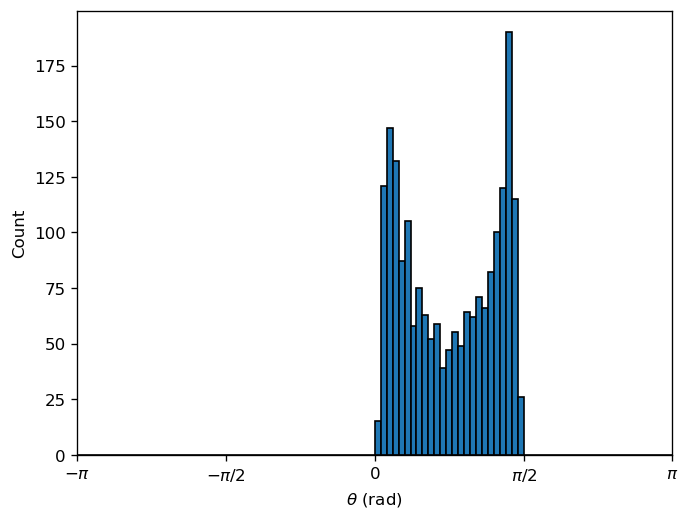

In [114]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.asarray(theta)                       # radians

fig, ax = plt.subplots()
ax.hist(theta, bins=100, range=(-np.pi, np.pi), edgecolor='black')

ax.set_xlabel(r'$\theta$ (rad)')
ax.set_ylabel('Count')
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks(np.arange(-np.pi, np.pi + 0.01, np.pi/2))
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
plt.show()

In [115]:
c1 = jnp.sum(pd["walkers"][0][:,0])
c2 = jnp.sum(pd["walkers"][0][:,1])
norm = jnp.sqrt(c1**2 + c2**2)
c1 = c1 / norm
c2 = c2 / norm
print(c1, c2)

(0.6979485420874711+0j) (0.7161479125138699+0j)


In [116]:
print(theta.max())
print(theta.min())

1.5412943864125035
0.04099816683394474


In [45]:
t0 = time.time()
DT, NSTEP, NBLK = 0.01, 10, 20

tau_fp, e_fp, err_fp = run_free_projection(
    ham_A, hamdata_A, trial_A, wave_A, nchol_A,
    dt=DT, n_walkers=200, n_prop_steps=NSTEP, n_blocks=NBLK, n_traj=5, seed=11)

# tau_ph, e_ph, err_ph, raw_ph, kill_ph = run_constrained(
#     propagator_uhf_gen, ham_A, hamdata_A, trial_A, wave_A, nchol_A,
#     dt=DT, n_walkers=200, n_prop_steps=NSTEP, n_blocks=NBLK, n_runs=3, seed=11)

tau_cp, e_cp, err_cp, raw_cp, kill_cp = run_constrained(
    propagator_cp, ham_A, hamdata_A, trial_A, wave_A, nchol_A,
    dt=DT, n_walkers=200, n_prop_steps=NSTEP, n_blocks=NBLK, n_runs=3, seed=11)

print("           tau      E(tau)          |E + t|")
for i in [0, NBLK // 2, NBLK - 1]:
    print(f"free proj  {tau_fp[i]:5.2f}  {e_fp[i]:+.12f}  {abs(e_fp[i]+T_HOP):.2e}")
    # print(f"phaseless  {tau_ph[i]:5.2f}  {e_ph[i]:+.12f}  {abs(e_ph[i]+T_HOP):.2e}")
    print(f"cons. path {tau_cp[i]:5.2f}  {e_cp[i]:+.12f}  {abs(e_cp[i]+T_HOP):.2e}")
    print()
# print("phaseless vs constrained path, max |difference| over all blocks and runs:",
#       np.max(np.abs(raw_ph - raw_cp)))
print(f"walkers killed by the constraint {kill_cp}")
print("elapsed %.1f s" % (time.time() - t0))

           tau      E(tau)          |E + t|
free proj   0.10  -1.000000000000  1.11e-16
cons. path  0.10  -1.000000000000  0.00e+00

free proj   1.10  -1.000000000000  0.00e+00
cons. path  1.10  -1.000000000000  0.00e+00

free proj   2.00  -1.000000000000  0.00e+00
cons. path  2.00  -1.000000000000  0.00e+00

walkers killed by the constraint 0
elapsed 2.0 s


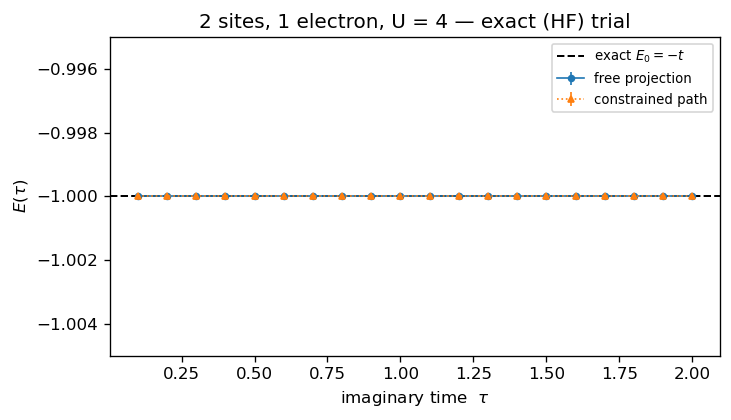

In [46]:
fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.axhline(-T_HOP, color="k", lw=1.2, ls="--", label=r"exact $E_0=-t$")
ax.errorbar(tau_fp, e_fp, err_fp, fmt="o-",  ms=3.5, lw=1, label="free projection")
ax.errorbar(tau_cp, e_cp, err_cp, fmt="^:",  ms=3.5, lw=1, label="constrained path")
ax.set_xlabel(r"imaginary time  $\tau$");  ax.set_ylabel(r"$E(\tau)$")
ax.set_title("2 sites, 1 electron, U = %g — exact (HF) trial" % U_INT)
ax.set_ylim(-1.0 - 5e-3, -1.0 + 5e-3)
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

Flat at $-t$ to $\sim10^{-16}$, and the phaseless and constrained-path trajectories are
**bit-for-bit identical** — with a real propagator the two weight updates are the same arithmetic.
No walker is ever killed, because the exact trial has no node the walkers can cross.

## 8. Seeing imaginary time actually do something: a deliberately bad trial

A flat line is reassuring but not very illuminating. To watch the projection work we keep the same
one-electron model but replace the trial by the *site-localised* determinant $|\Psi_T\rangle=|1\rangle$,
and start the walkers there as well. Then everything can be done by hand:

$$
|1\rangle=\tfrac{1}{\sqrt2}\big(|{\rm b}\rangle+|{\rm a}\rangle\big),\qquad
e^{-\tau\hat H}|1\rangle=\tfrac{1}{\sqrt2}\big(e^{+t\tau}|{\rm b}\rangle+e^{-t\tau}|{\rm a}\rangle\big),
$$

$$
\langle 1|e^{-\tau\hat H}|1\rangle=\cosh(t\tau),\qquad
\langle 1|\hat H e^{-\tau\hat H}|1\rangle=-t\sinh(t\tau),
$$

$$
\boxed{\;E_{\rm mix}(\tau)=-\,t\,\tanh(t\,\tau)\;}
$$

which starts at $E=0$ (the localised state has no kinetic energy) and decays to $-t$ with a rate
set by the gap $\Delta = E_{\rm a}-E_{\rm b}=2t$. Free projection is *exact*, so it must trace this
curve; the constrained methods must too, as long as the constraint never fires.

In [21]:
mo_local_a = np.array([[1.0], [0.0]])          # electron pinned to site 0
mo_local_b = np.zeros((N_SITES, 0))

ham_L, hamdata_L, nchol_L, trial_L, wave_L = afqmc_setup(
    h1_A, U_INT, NELEC_A, mo_local_a, mo_local_b, N_SITES)

DT, NSTEP, NBLK = 0.01, 10, 30

tau_fp_L, e_fp_L, err_fp_L = run_free_projection(
    ham_L, hamdata_L, trial_L, wave_L, nchol_L,
    dt=DT, n_walkers=500, n_prop_steps=NSTEP, n_blocks=NBLK, n_traj=16, seed=21)

tau_ph_L, e_ph_L, err_ph_L, raw_ph_L, kill_ph_L = run_constrained(
    propagator_uhf_gen, ham_L, hamdata_L, trial_L, wave_L, nchol_L,
    dt=DT, n_walkers=500, n_prop_steps=NSTEP, n_blocks=NBLK, n_runs=6, seed=21)

tau_cp_L, e_cp_L, err_cp_L, raw_cp_L, kill_cp_L = run_constrained(
    propagator_cp, ham_L, hamdata_L, trial_L, wave_L, nchol_L,
    dt=DT, n_walkers=500, n_prop_steps=NSTEP, n_blocks=NBLK, n_runs=6, seed=21)

e_exact_L = -T_HOP * np.tanh(T_HOP * tau_fp_L)

print("  tau     free proj            phaseless            cons. path        -t*tanh(t*tau)")
for i in range(0, NBLK, 4):
    print(f"{tau_fp_L[i]:5.2f}  {e_fp_L[i]:+.5f}+/-{err_fp_L[i]:.5f}   "
          f"{e_ph_L[i]:+.5f}+/-{err_ph_L[i]:.5f}   "
          f"{e_cp_L[i]:+.5f}+/-{err_cp_L[i]:.5f}   {e_exact_L[i]:+.5f}")
print("\nmax |phaseless - CP| =", np.max(np.abs(raw_ph_L - raw_cp_L)))
print("walkers killed by the constraint: phaseless %d, CP %d" % (kill_ph_L, kill_cp_L))

E0903 15:10:18.082174  821485 cuda_executor.cc:1213] [0] Failed to track device allocation: ALREADY_EXISTS: Allocation at address (nil) (size 0) is already tracked


  tau     free proj            phaseless            cons. path        -t*tanh(t*tau)
 0.10  -0.09885+/-0.00073   -0.09855+/-0.00101   -0.09855+/-0.00101   -0.09967
 0.50  -0.44482+/-0.00533   -0.47011+/-0.01463   -0.47011+/-0.01463   -0.46212
 0.90  -0.70007+/-0.01027   -0.67405+/-0.02175   -0.67405+/-0.02175   -0.71630
 1.30  -0.82393+/-0.01759   -0.78692+/-0.02962   -0.78692+/-0.02962   -0.86172
 1.70  -0.92574+/-0.01685   -0.92439+/-0.06367   -0.92439+/-0.06367   -0.93541
 2.10  -0.98718+/-0.01905   -0.91404+/-0.04362   -0.91404+/-0.04362   -0.97045
 2.50  -0.96695+/-0.02213   -0.92183+/-0.03805   -0.92183+/-0.03805   -0.98661
 2.90  -1.01656+/-0.02192   -0.93859+/-0.05725   -0.93859+/-0.05725   -0.99396

max |phaseless - CP| = 0.0
walkers killed by the constraint: phaseless 0, CP 0


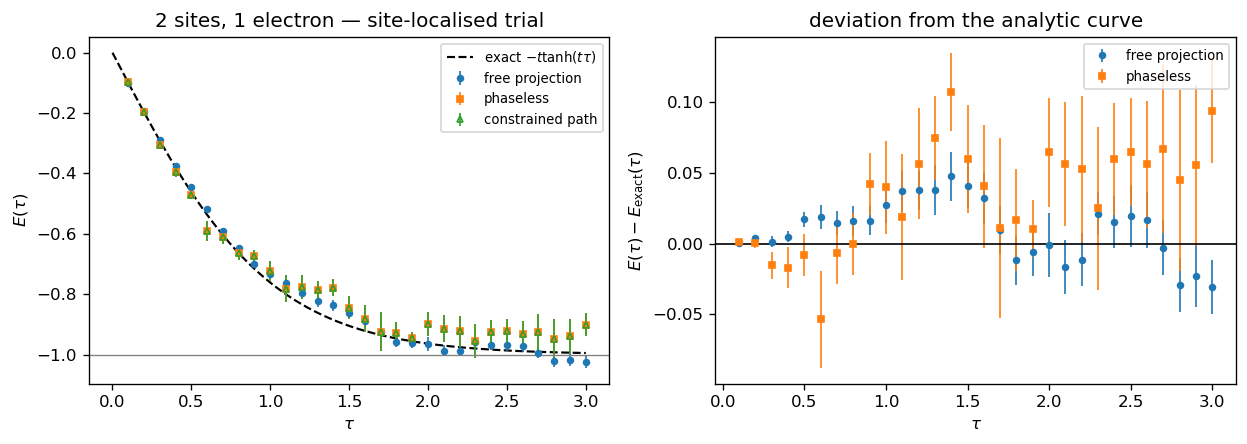

In [ ]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.8))

tt = np.linspace(0, tau_fp_L[-1], 400)
ax.plot(tt, -T_HOP*np.tanh(T_HOP*tt), "k--", lw=1.3, label=r"exact $-t\tanh(t\tau)$")
ax.errorbar(tau_fp_L, e_fp_L, err_fp_L, fmt="o",  ms=3.5, lw=1, label="free projection")
ax.errorbar(tau_ph_L, e_ph_L, err_ph_L, fmt="s",  ms=3.5, lw=1, label="phaseless")
ax.errorbar(tau_cp_L, e_cp_L, err_cp_L, fmt="^",  ms=3.5, lw=1, mfc="none", label="constrained path")
ax.axhline(-T_HOP, color="0.5", lw=0.8)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$E(\tau)$")
ax.set_title("2 sites, 1 electron — site-localised trial")
ax.legend(fontsize=8)

ax2.errorbar(tau_fp_L, e_fp_L - e_exact_L, err_fp_L, fmt="o", ms=3.5, lw=1, label="free projection")
ax2.errorbar(tau_ph_L, e_ph_L - e_exact_L, err_ph_L, fmt="s", ms=3.5, lw=1, label="phaseless")
ax2.axhline(0, color="k", lw=1)
ax2.set_xlabel(r"$\tau$"); ax2.set_ylabel(r"$E(\tau)-E_{\rm exact}(\tau)$")
ax2.set_title("deviation from the analytic curve")
ax2.legend(fontsize=8)
fig.tight_layout(); plt.show()

Free projection follows $-t\tanh(t\tau)$ within the error bars over the whole trajectory — the
propagator, the HS transformation and the mixed estimator are all correct. The constrained methods
follow the same curve here because the constraint never triggers (no walker crosses the node of a
positive-definite one-electron trial).

Note that the free-projection error bar *grows* with $\tau$ even in this trivial problem: the
weights $W_w$ spread exponentially. That growth is the generic reason free projection is
unaffordable for large systems and why the constrained methods exist.

---

# Walker analysis: what the QMC wavefunction looks like on the circle

For **one electron on two sites** an orthonormalised walker is just a unit vector in the site
basis, so it is fully specified by a single angle:

$$
|\phi_w\rangle \;=\; \cos\theta_w\,|1\rangle \;+\; \sin\theta_w\,|2\rangle ,
\qquad
\theta_w=\operatorname{atan2}\big(\phi_w[2],\,\phi_w[1]\big).
$$

$\theta=0$ is $|1\rangle$, $\theta=\pi/2$ is $|2\rangle$, and the exact ground state (the bonding
orbital) is $\theta=\pi/4$. The whole many-body Hilbert space is a circle, and the entire QMC
run can be watched as a swarm of points moving on it.

### Gauge: $(W,|\phi\rangle)$ and $(-W,-|\phi\rangle)$ are the same walker

A determinant is a *ray*: multiplying the occupied orbital by $-1$ flips the sign of every
overlap and every determinant, so it can be absorbed into the weight. `afqmc` keeps the weights
real and **non-negative** and parks the sign in the orbital (see `propagate_free`: the weight
takes `|constants|` and the phase is multiplied back into the columns). So $\theta$ genuinely
runs over the full circle $[-\pi,\pi)$, and $\theta$ and $\theta+\pi$ are the same determinant
with opposite coefficient.

For plotting, we fix the gauge by demanding a positive trial overlap,
$\langle\Psi_T|\phi\rangle>0$, which maps every walker into $\theta\in(-\pi/2,\pi/2]$.

### Reconstructing $|\Psi\rangle = c_1|1\rangle + c_2|2\rangle$

The two propagators represent the wavefunction *differently*, and this is the single most
important point of this section.

**Free projection** carries no importance sampling, so the ensemble is the wavefunction directly:

$$
|\Psi_{\rm FP}\rangle=\sum_w W_w\,|\phi_w\rangle
\qquad\Longrightarrow\qquad
c_1=\sum_w W_w\cos\theta_w,\quad c_2=\sum_w W_w\sin\theta_w .
$$

**Phaseless / constrained path** sample the *mixed* distribution
$f(\phi)=\langle\Psi_T|\phi\rangle\,\Psi(\phi)$ — the overlap with the trial has been folded into
the weight. To get the wavefunction back you must divide it out again:

$$
|\Psi_{\rm CP}\rangle=\sum_w \frac{W_w}{\langle\Psi_T|\phi_w\rangle}\,|\phi_w\rangle
\qquad\Longrightarrow\qquad
c_1=\sum_w \frac{W_w\cos\theta_w}{\langle\Psi_T|\phi_w\rangle},\quad
c_2=\sum_w \frac{W_w\sin\theta_w}{\langle\Psi_T|\phi_w\rangle}.
$$

Two checks that this is the right formula:

* it is invariant under the walker gauge flip $(W,\phi)\to(W,-\phi)$ — which matters, because
  `sampler.prop_nstep` calls `orthonormalize_walkers`, and that **discards the sign returned by
  the QR**, so constrained-path walkers routinely come back globally flipped;
* it reproduces the sampler's own energy exactly:
  $\dfrac{\langle\Psi_T|\hat H|\Psi_{\rm CP}\rangle}{\langle\Psi_T|\Psi_{\rm CP}\rangle}
  =\dfrac{\sum_w W_w E_L[\phi_w]}{\sum_w W_w}$, the mixed estimator.

Since the Hilbert space is only two-dimensional we can go further than the mixed estimator and
evaluate the **variational** energy of the reconstructed state,
$E_{\rm var}=\mathbf c^{\mathsf T}h_1\mathbf c/\mathbf c^{\mathsf T}\mathbf c$, which is a much
sharper test of the wavefunction (second order in the error of $\mathbf c$, rather than first).

In [13]:
# ---------------------------------------------------------------------------
# Walker <-> angle utilities, and the non-exact (site-localised) trial |1>
# ---------------------------------------------------------------------------
H_1E = h1_A                                  # for one electron the full H is just the hopping
V_T  = np.array([1.0, 0.0])                  # trial |Psi_T> = |1>  (site-localised, NOT exact)

def walker_matrix(prop_data):
    "(n_walkers, 2) array of real site amplitudes of the alpha determinant."
    w = np.asarray(prop_data["walkers"][0])[:, :, 0]
    assert np.abs(w.imag).max() < 1e-12, "walkers should be real for the spin decomposition"
    return w.real

def theta_of(w):
    "Angle on the circle:  |phi> = cos(theta)|1> + sin(theta)|2>."
    return np.arctan2(w[:, 1], w[:, 0])

def gauge_fix(theta):
    "Map theta -> the representative with <1|phi> > 0, i.e. theta in (-pi/2, pi/2]."
    return (theta + np.pi / 2) % np.pi - np.pi / 2

def reconstruct(w, weights, overlaps=None):
    """
    Unnormalised (c1, c2).

    overlaps=None  -> free projection,      |Psi> = sum_w W_w |phi_w>
    overlaps given -> importance sampled,   |Psi> = sum_w (W_w / <Psi_T|phi_w>) |phi_w>
    """
    coef = weights if overlaps is None else weights / overlaps
    return (coef[:, None] * w).sum(0)

def summarize(c):
    "Normalise, fix the overall sign, and report (c, theta_eff, E_variational, E_mixed)."
    cc = c / np.linalg.norm(c)
    if cc[0] < 0:
        cc = -cc
    e_var = float(cc @ H_1E @ cc)
    e_mix = float((V_T @ H_1E @ cc) / (V_T @ cc))
    return cc, float(np.arctan2(cc[1], cc[0])), e_var, e_mix

THETA_EXACT = np.pi / 4
print("exact ground state:  theta = %.6f   c = (%.6f, %.6f)   E = %+.1f"
      % (THETA_EXACT, np.cos(THETA_EXACT), np.sin(THETA_EXACT), -T_HOP))

# the non-exact trial: electron pinned to site 0
mo_loc_a = np.array([[1.0], [0.0]])
mo_loc_b = np.zeros((N_SITES, 0))
ham_W, hamdata_W, nchol_W, trial_W, wave_W = afqmc_setup(
    h1_A, U_INT, NELEC_A, mo_loc_a, mo_loc_b, N_SITES)
print("\ntrial <Psi_T| = <1| :  E_trial = %+.6f  (vs exact %+.1f)"
      % (float(V_T @ H_1E @ V_T), -T_HOP))

exact ground state:  theta = 0.785398   c = (0.707107, 0.707107)   E = -1.0

trial <Psi_T| = <1| :  E_trial = +0.000000  (vs exact -1.0)


E0904 00:48:32.837244  854395 cuda_executor.cc:1213] [0] Failed to track device allocation: ALREADY_EXISTS: Allocation at address (nil) (size 0) is already tracked


## Choosing the time step: why this trial is harder than it looks

With the site-localised trial the local energy is

$$
E_L[\phi]=\frac{\langle 1|\hat H|\phi\rangle}{\langle 1|\phi\rangle}
=\frac{-t\sin\theta}{\cos\theta}=-t\tan\theta ,
$$

which **diverges at the node** $\theta=\pi/2$, and so does the force bias
$\bar x\propto\langle\hat L\rangle_{\rm mix}$. Walkers do get close to that node, so the
importance-sampled propagator has a much larger Trotter error than it did with the exact trial
in section 7 — even though the *constraint itself never fires*. The scan below isolates it:
the answer is essentially independent of the Taylor order used for $e^{\hat v_{\rm HS}}$ and of
the walker number, but strongly dependent on $\Delta\tau$, with the expected $\mathcal O(\Delta\tau^2)$
scaling.

In [14]:
def cp_energy(dt, n_prop_steps, n_walkers=1000, n_exp_terms=10,
              n_runs=4, tau_max=12.0, tau_eq=5.0, seed=11):
    "Constrained-path energy averaged over tau > tau_eq, from n_runs independent walks."
    prop = propagator_cp(dt=dt, n_walkers=n_walkers, n_exp_terms=n_exp_terms, n_batch=1)
    hd   = ham_W.build_propagation_intermediates(dict(hamdata_W), prop, trial_W, wave_W)
    smp  = sampling.sampler(n_prop_steps=n_prop_steps, n_blocks=1, n_chol=nchol_W)
    blk  = dt * n_prop_steps
    n_blocks = int(round(tau_max / blk))
    per_run = []
    for key in random.split(random.PRNGKey(seed), n_runs):
        pd = prop.init_prop_data(trial_W, wave_W, hd, None)
        pd["key"] = key; pd["n_killed_walkers"] = 0
        es = []
        for b in range(n_blocks):
            pd, (wt, en, er) = smp.block_sample(pd, hd, prop, trial_W, wave_W)
            if blk * (b + 1) > tau_eq:
                es.append(float(en))
        per_run.append(np.mean(es))
    per_run = np.array(per_run)
    return per_run.mean(), per_run.std(ddof=1) / np.sqrt(n_runs)

t0 = time.time()
print("constrained path, site-localised trial   (exact E0 = -1)")
print("  dt      n_exp  n_walkers      E")
for nexp in (6, 10, 20):
    m, e = cp_energy(0.01, 10, n_exp_terms=nexp)
    print(f"  0.01    {nexp:3d}     1000      {m:+.5f} +/- {e:.5f}")
for nw in (4000,):
    m, e = cp_energy(0.01, 10, n_walkers=nw)
    print(f"  0.01     10     {nw:4d}      {m:+.5f} +/- {e:.5f}")
for dt, ns in ((0.005, 20), (0.0025, 40)):
    m, e = cp_energy(dt, ns)
    print(f"  {dt:<6}   10     1000      {m:+.5f} +/- {e:.5f}")
print("\nelapsed %.0f s" % (time.time() - t0))
print("-> the Taylor order and the walker number barely matter; dt does, with error ~ dt^2.")
print("   Everything below uses dt = 0.0025 with 40 steps per block (block time 0.1).")

constrained path, site-localised trial   (exact E0 = -1)
  dt      n_exp  n_walkers      E
  0.01      6     1000      -0.91014 +/- 0.01398
  0.01     10     1000      -0.91363 +/- 0.00924
  0.01     20     1000      -0.91363 +/- 0.00924
  0.01     10     4000      -0.92650 +/- 0.00686
  0.005    10     1000      -0.99044 +/- 0.00980
  0.0025   10     1000      -1.00735 +/- 0.00633

elapsed 36 s
-> the Taylor order and the walker number barely matter; dt does, with error ~ dt^2.
   Everything below uses dt = 0.0025 with 40 steps per block (block time 0.1).


## Energy convergence: when has the walk equilibrated?

With $|\Psi_T\rangle=|\Phi_0\rangle=|1\rangle$ the mixed estimator is known in closed form
(section 8),

$$E_{\rm mix}(\tau)=-t\tanh(t\tau),$$

so the projection is complete to a relative accuracy $\epsilon$ once
$1-\tanh(t\tau)<\epsilon$, i.e. $t\tau\gtrsim\tfrac12\ln(2/\epsilon)$. For $\epsilon=10^{-3}$
that is $\tau\simeq3.8$. We therefore treat $\tau>5$ as equilibrated and sample walkers only
beyond that point.

In [15]:
DT_W, NSTEP_W = 0.0025, 40                 # block time = 0.1
BLK_W  = DT_W * NSTEP_W
TAU_EQ = 5.0
NW_W   = 1000

def run_fp_collect(n_blocks, n_traj, seed=11, tau_snap=None):
    """
    Free projection.  Returns per-block energies (n_traj, n_blocks) and, for each tau in
    `tau_snap`, the list of per-trajectory walker snapshots taken at the END of that block.
    """
    prop = propagator_uhf_gen(dt=DT_W, n_walkers=NW_W, n_exp_terms=10, n_batch=1)
    hd   = ham_W.build_propagation_intermediates(dict(hamdata_W), prop, trial_W, wave_W)
    smp  = fp_sampler_gen(n_prop_steps=NSTEP_W, n_eql_blocks=1, n_trj=1, n_chol=nchol_W)
    snap_blocks = None if tau_snap is None else {int(round(t / BLK_W)) - 1 for t in tau_snap}

    energies, snaps = [], {}
    for key in random.split(random.PRNGKey(seed), n_traj):
        pd = prop.init_prop_data(trial_W, wave_W, hd, None)
        pd["key"] = key
        e_traj = []
        for b in range(n_blocks):
            pd, (blk_w, blk_e) = smp.fp_block(pd, hd, prop, trial_W, wave_W)
            e_traj.append(complex(blk_e).real)
            if snap_blocks is not None and b in snap_blocks:
                snaps.setdefault(round(BLK_W * (b + 1), 4), []).append(
                    (walker_matrix(pd),
                     np.asarray(pd["weights"]).real.copy(),
                     np.asarray(pd["overlaps"]).real.copy()))
        energies.append(e_traj)
    tau = BLK_W * np.arange(1, n_blocks + 1)
    return tau, np.array(energies), snaps


def run_cp_collect(n_blocks, n_runs, seed=11, snap_every=5, tau_eq=TAU_EQ):
    """
    Constrained path.  Returns per-block energies (n_runs, n_blocks) and a list of
    (run index, tau, walkers, weights, overlaps) snapshots taken after equilibration.
    """
    prop = propagator_cp(dt=DT_W, n_walkers=NW_W, n_exp_terms=10, n_batch=1)
    hd   = ham_W.build_propagation_intermediates(dict(hamdata_W), prop, trial_W, wave_W)
    smp  = sampling.sampler(n_prop_steps=NSTEP_W, n_blocks=1, n_chol=nchol_W)

    energies, snaps, killed = [], [], 0
    for r, key in enumerate(random.split(random.PRNGKey(seed), n_runs)):
        pd = prop.init_prop_data(trial_W, wave_W, hd, None)
        pd["key"] = key; pd["n_killed_walkers"] = 0
        e_run = []
        for b in range(n_blocks):
            pd, (wt, en, er) = smp.block_sample(pd, hd, prop, trial_W, wave_W)
            e_run.append(float(en))
            tau = BLK_W * (b + 1)
            if tau > tau_eq and b % snap_every == 0:
                snaps.append((r, tau, walker_matrix(pd),
                              np.asarray(pd["weights"]).real.copy(),
                              np.asarray(pd["overlaps"]).real.copy()))
        killed += int(pd["n_killed_walkers"])
        energies.append(e_run)
    tau = BLK_W * np.arange(1, n_blocks + 1)
    return tau, np.array(energies), snaps, killed


t0 = time.time()
TAU_SNAP = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
tau_fp_w, e_fp_w, fp_snaps = run_fp_collect(n_blocks=60, n_traj=24, tau_snap=TAU_SNAP)
tau_cp_w, e_cp_w, cp_snaps, cp_killed = run_cp_collect(n_blocks=120, n_runs=8)
print("free projection : %d trajectories x %d blocks" % e_fp_w.shape)
print("constrained path: %d runs x %d blocks, %d post-equilibration snapshots, %d walkers killed"
      % (e_cp_w.shape[0], e_cp_w.shape[1], len(cp_snaps), cp_killed))
print("elapsed %.0f s" % (time.time() - t0))

free projection : 24 trajectories x 60 blocks
constrained path: 8 runs x 120 blocks, 112 post-equilibration snapshots, 0 walkers killed
elapsed 37 s


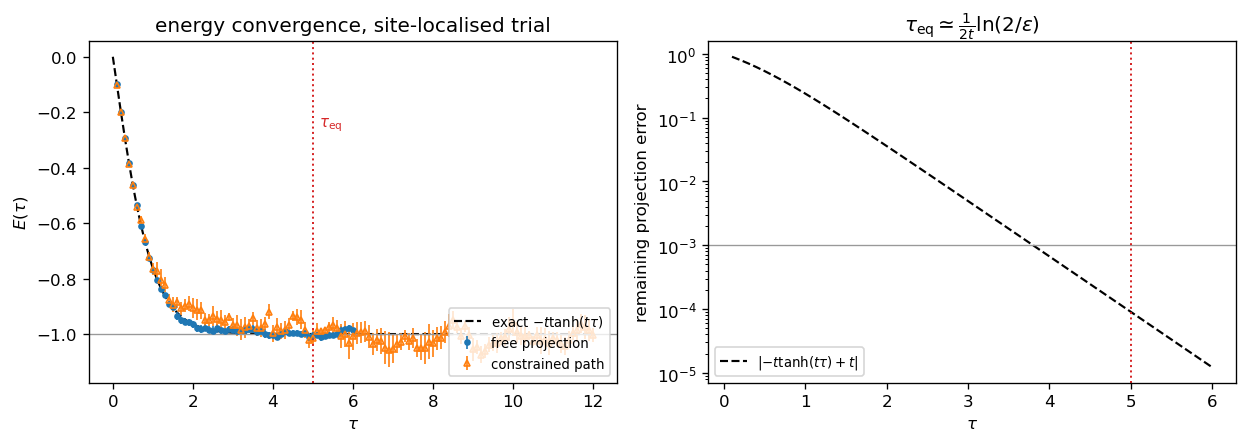

E(tau>5): free projection -0.99624 +/- 0.00756 | constrained path -1.01210 +/- 0.01208


In [16]:
e_exact_w = -T_HOP * np.tanh(T_HOP * tau_fp_w)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10.5, 3.8))
tt = np.linspace(0, tau_cp_w[-1], 500)
axL.plot(tt, -T_HOP * np.tanh(T_HOP * tt), "k--", lw=1.3, label=r"exact $-t\tanh(t\tau)$")
axL.errorbar(tau_fp_w, e_fp_w.mean(0), e_fp_w.std(0, ddof=1) / np.sqrt(e_fp_w.shape[0]),
             fmt="o", ms=3, lw=1, label="free projection")
axL.errorbar(tau_cp_w, e_cp_w.mean(0), e_cp_w.std(0, ddof=1) / np.sqrt(e_cp_w.shape[0]),
             fmt="^", ms=3.5, lw=1, mfc="none", label="constrained path")
axL.axhline(-T_HOP, color="0.6", lw=0.8)
axL.axvline(TAU_EQ, color="C3", ls=":", lw=1.2)
axL.text(TAU_EQ + 0.15, -0.25, r"$\tau_{\rm eq}$", color="C3", fontsize=9)
axL.set_xlabel(r"$\tau$"); axL.set_ylabel(r"$E(\tau)$")
axL.set_title("energy convergence, site-localised trial")
axL.legend(fontsize=8, loc="lower right")

axR.semilogy(tau_fp_w, np.abs(e_exact_w + T_HOP), "k--", lw=1.3,
             label=r"$|{-t\tanh(t\tau)} + t|$")
axR.axhline(1e-3, color="0.6", lw=0.8)
axR.axvline(TAU_EQ, color="C3", ls=":", lw=1.2)
axR.set_xlabel(r"$\tau$"); axR.set_ylabel("remaining projection error")
axR.set_title(r"$\tau_{\rm eq}\simeq\frac{1}{2t}\ln(2/\epsilon)$")
axR.legend(fontsize=8)
fig.tight_layout(); plt.show()

print("E(tau>5): free projection %+.5f +/- %.5f | constrained path %+.5f +/- %.5f"
      % (e_fp_w[:, 50:].mean(),
         e_fp_w[:, 50:].mean(1).std(ddof=1) / np.sqrt(e_fp_w.shape[0]),
         e_cp_w[:, 50:].mean(),
         e_cp_w[:, 50:].mean(1).std(ddof=1) / np.sqrt(e_cp_w.shape[0])))

## The distribution of $\theta$

Free projection is started from the trial, so at $\tau=0$ every walker sits at $\theta=0$
(a delta function at $|1\rangle$). As $\tau$ grows the swarm spreads out and settles into a
stationary distribution.

Two features of this model are worth noting before looking at the plot:

* Both factors of the propagator have **non-negative** matrix elements — the hopping factor is
  $e^{-\Delta\tau h_1}=\cosh(\Delta\tau t)\,\mathbb 1+\sinh(\Delta\tau t)\,\sigma_x$, and the
  spin-decomposed field operator $e^{\sqrt{\Delta\tau U}\,x\,\hat n_\gamma}$ is a positive
  diagonal. A positive matrix maps the positive quadrant into itself, so a walker started at
  $\theta=0$ can **never leave** $\theta\in[0,\pi/2]$. There is literally no sign problem in
  this model, which is why free projection is stable here and why the constraint never fires.
* $\theta=0$ and $\theta=\pi/2$ are the attracting fixed points of the diagonal field operator,
  so the walker density piles up at both edges — the distribution is bathtub-shaped, not peaked
  at the answer. The ground state emerges from the *coherent sum*, not from any individual walker.

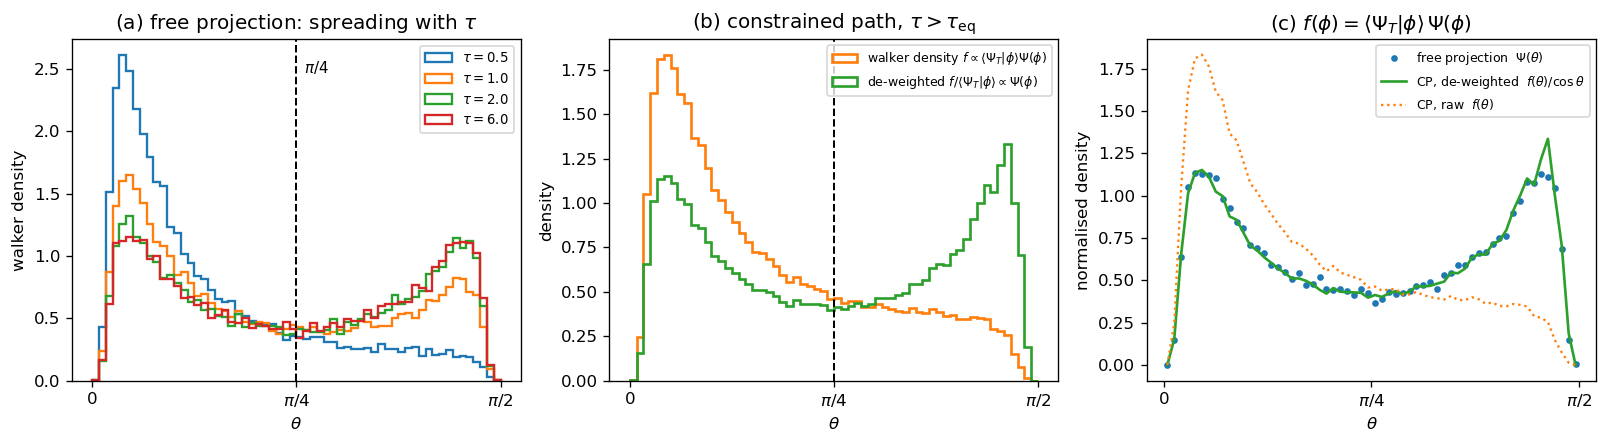

raw theta range, free projection : [+0.0247, +1.5497]   (positive quadrant -> no sign problem)
raw theta range, constrained path: [-3.1210, -1.6083]
  -> globally sign-flipped by the QR inside `orthonormalize_walkers`;
     gauge-fixed range is [+0.0206, +1.5333], still inside the positive quadrant.
mean theta:  FP 0.7830 | CP raw 0.5380 (pulled toward the trial at 0) | CP de-weighted 0.7913
reflection symmetry of the FP density about pi/4 (theta -> pi/2 - theta): max relative deviation 0.074


In [17]:
def hist_data(snap_list, importance):
    "Pool snapshots -> (gauge-fixed theta, weight, |wavefunction weight|)."
    th, wt, dw = [], [], []
    for item in snap_list:
        w, weights, overlaps = item[-3:]
        t = theta_of(w)
        th.append(gauge_fix(t))
        wt.append(weights)
        dw.append(np.abs(weights / overlaps) if importance else weights)
    return np.concatenate(th), np.concatenate(wt), np.concatenate(dw)

bins = np.linspace(0.0, np.pi / 2, 61)
ctr  = 0.5 * (bins[1:] + bins[:-1])

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

# --- (a) free projection, several tau ---------------------------------------
ax = axes[0]
for tau in [0.5, 1.0, 2.0, 6.0]:
    th, wt, _ = hist_data(fp_snaps[tau], importance=False)
    ax.hist(th, bins=bins, weights=wt, density=True, histtype="step", lw=1.4,
            label=r"$\tau=%.1f$" % tau)
ax.axvline(THETA_EXACT, color="k", ls="--", lw=1.2)
ax.text(THETA_EXACT + 0.03, ax.get_ylim()[1] * 0.9, r"$\pi/4$", fontsize=9)
ax.set_xlabel(r"$\theta$"); ax.set_ylabel("walker density")
ax.set_title("(a) free projection: spreading with $\\tau$")
ax.set_xticks([0, np.pi/4, np.pi/2]); ax.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$"])
ax.legend(fontsize=8)

# --- (b) constrained path: raw vs de-weighted -------------------------------
ax = axes[1]
th_cp, wt_cp, dw_cp = hist_data(cp_snaps, importance=True)
ax.hist(th_cp, bins=bins, weights=wt_cp, density=True, histtype="step", lw=1.6, color="C1",
        label=r"walker density $f\propto\langle\Psi_T|\phi\rangle\Psi(\phi)$")
ax.hist(th_cp, bins=bins, weights=dw_cp, density=True, histtype="step", lw=1.6, color="C2",
        label=r"de-weighted $f/\langle\Psi_T|\phi\rangle\propto\Psi(\phi)$")
ax.axvline(THETA_EXACT, color="k", ls="--", lw=1.2)
ax.set_xlabel(r"$\theta$"); ax.set_ylabel("density")
ax.set_title(r"(b) constrained path, $\tau>\tau_{\rm eq}$")
ax.set_xticks([0, np.pi/4, np.pi/2]); ax.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$"])
ax.legend(fontsize=7.5)

# --- (c) the mixed-distribution identity ------------------------------------
ax = axes[2]
th_fp, wt_fp, _ = hist_data([s for t in TAU_SNAP if t >= 5.0 for s in fp_snaps[t]],
                            importance=False)
h_fp,  _ = np.histogram(th_fp, bins=bins, weights=wt_fp, density=True)
h_cp,  _ = np.histogram(th_cp, bins=bins, weights=wt_cp, density=True)
h_cpd, _ = np.histogram(th_cp, bins=bins, weights=dw_cp, density=True)
norm = lambda h: h / np.trapezoid(h, ctr)
ax.plot(ctr, norm(h_fp),  "o", ms=3, color="C0", label=r"free projection  $\Psi(\theta)$")
ax.plot(ctr, norm(h_cpd), "-", lw=1.6, color="C2",
        label=r"CP, de-weighted  $f(\theta)/\cos\theta$")
ax.plot(ctr, norm(h_cp),  ":", lw=1.4, color="C1", label=r"CP, raw  $f(\theta)$")
ax.set_xlabel(r"$\theta$"); ax.set_ylabel("normalised density")
ax.set_title(r"(c) $f(\phi)=\langle\Psi_T|\phi\rangle\,\Psi(\phi)$")
ax.set_xticks([0, np.pi/4, np.pi/2]); ax.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$"])
ax.legend(fontsize=7.5)

fig.tight_layout(); plt.show()

print("raw theta range, free projection : [%+.4f, %+.4f]   (positive quadrant -> no sign problem)"
      % (np.concatenate([theta_of(s[0]) for s in fp_snaps[6.0]]).min(),
         np.concatenate([theta_of(s[0]) for s in fp_snaps[6.0]]).max()))
raw_cp = np.concatenate([theta_of(s[2]) for s in cp_snaps])
print("raw theta range, constrained path: [%+.4f, %+.4f]" % (raw_cp.min(), raw_cp.max()))
print("  -> globally sign-flipped by the QR inside `orthonormalize_walkers`;")
print("     gauge-fixed range is [%+.4f, %+.4f], still inside the positive quadrant."
      % (gauge_fix(raw_cp).min(), gauge_fix(raw_cp).max()))
print("mean theta:  FP %.4f | CP raw %.4f (pulled toward the trial at 0) | CP de-weighted %.4f"
      % (np.average(th_fp, weights=wt_fp),
         np.average(th_cp, weights=wt_cp),
         np.average(th_cp, weights=dw_cp)))
sym = np.abs(norm(h_fp) - norm(h_fp)[::-1]).max() / norm(h_fp).max()
print("reflection symmetry of the FP density about pi/4 (theta -> pi/2 - theta):"
      " max relative deviation %.3f" % sym)

## The coefficients $c_1$, $c_2$

Now collapse each swarm onto a single vector. For free projection the walkers are collected at
the end of each of the 24 independent trajectories; for constrained path they are collected at
many times $\tau>\tau_{\rm eq}$ along 8 independent runs. Error bars come from the scatter
between trajectories/runs, never between blocks of one walk.

In [18]:
def coefficients(snap_list, importance, group):
    """
    Reconstruct (c1, c2) for each snapshot and average.
    `group` labels statistically independent walks; the error bar is their scatter.
    """
    cs, ths, evs, ems = [], [], [], []
    for item in snap_list:
        w, weights, overlaps = item[-3:]
        c = reconstruct(w, weights, overlaps if importance else None)
        cc, th, ev, em = summarize(c)
        cs.append(cc); ths.append(th); evs.append(ev); ems.append(em)
    cs, ths = np.array(cs), np.array(ths)
    group = np.asarray(group)
    per = np.array([ths[group == g].mean() for g in np.unique(group)])
    th_m = per.mean(); th_e = per.std(ddof=1) / np.sqrt(per.size)
    return dict(theta=th_m, theta_err=th_e,
                c1=np.cos(th_m), c2=np.sin(th_m),
                c1_err=abs(np.sin(th_m)) * th_e, c2_err=abs(np.cos(th_m)) * th_e,
                e_var=np.mean(evs), e_mix=np.mean(ems), n=len(cs))

print("FREE PROJECTION   (24 independent trajectories, walkers taken at the end of each)")
print("  tau      theta_eff              c1                  c2           E_var(recon)")
fp_tab = {}
for tau in TAU_SNAP:
    r = coefficients(fp_snaps[tau], importance=False, group=np.arange(len(fp_snaps[tau])))
    fp_tab[tau] = r
    print(f" {tau:4.1f}   {r['theta']:.5f}+/-{r['theta_err']:.5f}   "
          f"{r['c1']:.5f}+/-{r['c1_err']:.5f}   {r['c2']:.5f}+/-{r['c2_err']:.5f}   {r['e_var']:+.6f}")

cp_groups = [s[0] for s in cp_snaps]
r_cp = coefficients(cp_snaps, importance=True, group=cp_groups)
print("\nCONSTRAINED PATH  (%d snapshots with tau>%.1f, from %d independent runs)"
      % (r_cp["n"], TAU_EQ, len(set(cp_groups))))
print(f"        theta_eff              c1                  c2           E_var(recon)")
print(f"        {r_cp['theta']:.5f}+/-{r_cp['theta_err']:.5f}   "
      f"{r_cp['c1']:.5f}+/-{r_cp['c1_err']:.5f}   {r_cp['c2']:.5f}+/-{r_cp['c2_err']:.5f}   "
      f"{r_cp['e_var']:+.6f}")

print("\nEXACT             %.5f              %.5f              %.5f          %+.6f"
      % (THETA_EXACT, np.cos(THETA_EXACT), np.sin(THETA_EXACT), -T_HOP))

# consistency: the reconstruction must reproduce the sampler's own mixed estimator
print("\nconsistency check  E_mix from the reconstructed |Psi> vs the sampler's E(tau):")
print("  free projection   %+.5f   vs  %+.5f" % (fp_tab[6.0]["e_mix"], e_fp_w[:, -1].mean()))
print("  constrained path  %+.5f   vs  %+.5f" % (r_cp["e_mix"], e_cp_w[:, 50:].mean()))

FREE PROJECTION   (24 independent trajectories, walkers taken at the end of each)
  tau      theta_eff              c1                  c2           E_var(recon)
  0.5   0.43310+/-0.00413   0.90767+/-0.00174   0.41969+/-0.00375   -0.761273
  1.0   0.65674+/-0.00420   0.79199+/-0.00257   0.61054+/-0.00333   -0.966292
  2.0   0.76656+/-0.00661   0.72030+/-0.00458   0.69366+/-0.00476   -0.997285
  3.0   0.77719+/-0.00646   0.71289+/-0.00453   0.70128+/-0.00461   -0.997947
  4.0   0.78673+/-0.00732   0.70617+/-0.00518   0.70805+/-0.00517   -0.997536
  5.0   0.78749+/-0.00556   0.70563+/-0.00394   0.70858+/-0.00392   -0.998570
  6.0   0.77825+/-0.00514   0.71214+/-0.00361   0.70204+/-0.00366   -0.998685

CONSTRAINED PATH  (112 snapshots with tau>5.0, from 8 independent runs)
        theta_eff              c1                  c2           E_var(recon)
        0.78940+/-0.00576   0.70427+/-0.00409   0.70993+/-0.00406   -0.995817

EXACT             0.78540              0.70711              0.7

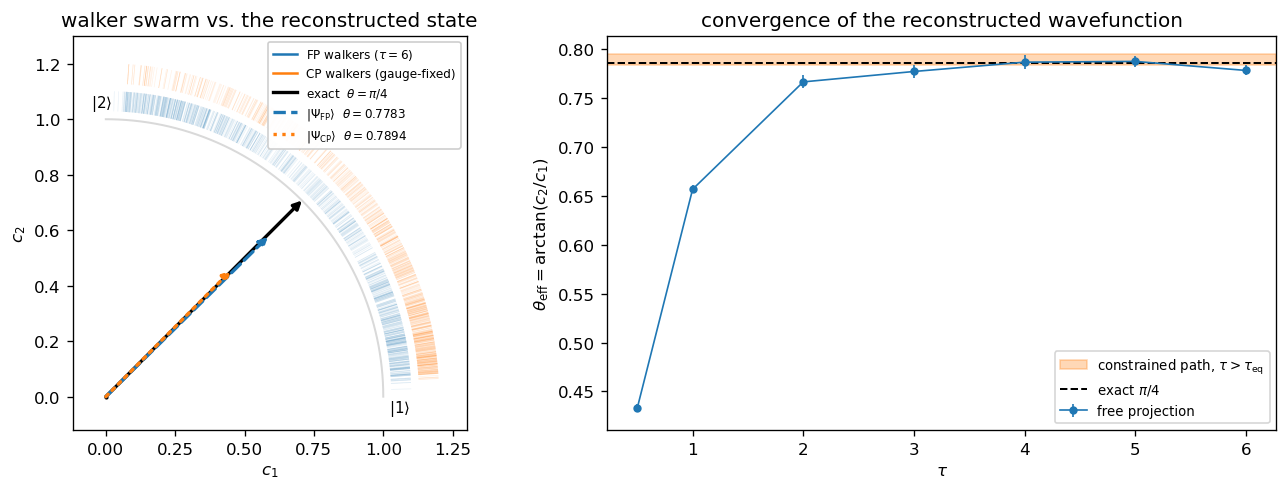

In [19]:
fig = plt.figure(figsize=(11.2, 4.2))
gs  = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.35])

# --- walkers on the unit circle, reconstructed states as arrows ---------------
ax  = fig.add_subplot(gs[0])
arc = np.linspace(0, np.pi / 2, 300)
ax.plot(np.cos(arc), np.sin(arc), color="0.85", lw=1.2, zorder=0)

def rug(theta, r0, r1, color, label):
    "Short radial ticks at angle theta -- a rug plot of the walker density on the arc."
    x = np.stack([r0 * np.cos(theta), r1 * np.cos(theta)])
    y = np.stack([r0 * np.sin(theta), r1 * np.sin(theta)])
    ax.plot(x, y, color=color, lw=0.4, alpha=0.10, zorder=1)
    ax.plot([], [], color=color, lw=1.5, label=label)

rug(theta_of(fp_snaps[6.0][0][0]), 1.03, 1.10, "C0", r"FP walkers ($\tau=6$)")
rug(gauge_fix(theta_of(cp_snaps[-1][2])), 1.13, 1.20, "C1", "CP walkers (gauge-fixed)")

# arrows drawn at different lengths so all three stay visible (they nearly coincide)
for th, rad, col, ls, lab in [
        (THETA_EXACT,          1.00, "k",  "-",  r"exact  $\theta=\pi/4$"),
        (fp_tab[6.0]["theta"], 0.82, "C0", "--", r"$|\Psi_{\rm FP}\rangle$  $\theta=%.4f$" % fp_tab[6.0]["theta"]),
        (r_cp["theta"],        0.64, "C1", ":",  r"$|\Psi_{\rm CP}\rangle$  $\theta=%.4f$" % r_cp["theta"])]:
    ax.annotate("", xy=(rad * np.cos(th), rad * np.sin(th)), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=2.0, color=col, ls=ls,
                                shrinkA=0, shrinkB=0), zorder=3)
    ax.plot([], [], color=col, lw=2.0, ls=ls, label=lab)

ax.plot(0, 0, "k.", ms=3)
ax.text(1.06, -0.055, r"$|1\rangle$", ha="center", fontsize=9)
ax.text(-0.055, 1.06, r"$|2\rangle$", va="center", fontsize=9)
ax.set_xlabel(r"$c_1$"); ax.set_ylabel(r"$c_2$")
ax.set_aspect("equal"); ax.set_xlim(-0.12, 1.30); ax.set_ylim(-0.12, 1.30)
ax.set_title("walker swarm vs. the reconstructed state")
ax.legend(fontsize=7.2, loc="upper right", framealpha=0.95)

# --- theta_eff vs tau --------------------------------------------------------
ax  = fig.add_subplot(gs[1])
ts  = np.array(TAU_SNAP)
th  = np.array([fp_tab[t]["theta"] for t in ts])
the = np.array([fp_tab[t]["theta_err"] for t in ts])
ax.errorbar(ts, th, the, fmt="o-", ms=4, lw=1, color="C0", label="free projection")
ax.axhspan(r_cp["theta"] - r_cp["theta_err"], r_cp["theta"] + r_cp["theta_err"],
           color="C1", alpha=0.30, label=r"constrained path, $\tau>\tau_{\rm eq}$")
ax.axhline(THETA_EXACT, color="k", ls="--", lw=1.2, label=r"exact $\pi/4$")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$\theta_{\rm eff}=\arctan(c_2/c_1)$")
ax.set_title("convergence of the reconstructed wavefunction")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()

## What this shows

* **The walker swarm is not the answer; the coherent sum is.** The stationary $\theta$
  distribution is bathtub-shaped, piled up at $|1\rangle$ and $|2\rangle$, with a *minimum* near
  the ground state $\pi/4$. No single walker resembles $|\Psi_0\rangle$; the weighted vector sum
  does, to three decimal places.

* **The distribution is nearly symmetric about $\pi/4$** (7% max deviation), i.e. under the site exchange
  $\theta\to\pi/2-\theta$, even though the trial $|1\rangle$ badly breaks that symmetry. The
  ensemble has forgotten the trial; only the constrained-path *weights* still remember it.

* **Free projection and constrained path represent the wavefunction differently.** Panel (b)
  shows the raw constrained-path walker density is skewed toward the trial (mean
  $\theta\approx0.54$ instead of $0.78$) because it samples the mixed distribution
  $f(\phi)=\langle\Psi_T|\phi\rangle\Psi(\phi)$. Dividing by $\langle\Psi_T|\phi\rangle$ puts it
  back on top of the free-projection density in panel (c) — a direct numerical verification of
  the importance-sampling identity, and the reason the $1/\langle\Psi_T|\phi_w\rangle$ factor
  belongs in the reconstruction.

* **The constraint never fires here.** The propagator is a positive matrix, so walkers started in
  the positive quadrant stay there and $\langle 1|\phi\rangle=\cos\theta$ never changes sign. The
  constrained-path result is therefore unbiased, and equals free projection.

* **What actually limits the accuracy is the time step**, not the constraint. Because
  $E_L=-t\tan\theta$ diverges at the node and walkers do approach it, the localised trial needs
  $\Delta\tau\lesssim0.0025$; at $\Delta\tau=0.01$ the energy is off by $0.09$ with error bars
  ten times smaller than that.

* **The variational energy of the reconstructed state is much sharper than the mixed estimator.**
  Because we have the whole (two-dimensional) Hilbert space we can evaluate
  $\mathbf c^{\mathsf T}h_1\mathbf c$: it is within $\sim10^{-3}$ of $-t$ well before the mixed
  estimator has settled, since it is second order rather than first order in the error of
  $\mathbf c$.

---

# Appendix: why a walker can never leave $\theta\in[0,\pi/2]$

The claim above — *"a positive matrix maps the positive quadrant into itself, so a walker started
at $\theta=0$ can never leave $\theta\in[0,\pi/2]$"* — packs three separate statements together.
Here they are in full.

## Step 1 — the geometric fact

Let

$$K=\{\phi\in\mathbb R^{2}:\ \phi_1\ge0,\ \phi_2\ge0\}$$

be the closed first quadrant, i.e. $\theta\in[0,\pi/2]$. If a matrix $M$ has all entries
$M_{ij}\ge0$, then for any $\phi\in K$

$$(M\phi)_i=\sum_j M_{ij}\,\phi_j\ \ge\ 0 ,$$

because every term is a product of two non-negative numbers. Hence $MK\subseteq K$. And a product
of entrywise non-negative matrices is again entrywise non-negative, so *any* composition of such
maps preserves $K$. That is the entire argument: no minus signs anywhere, therefore no
cancellation is possible.

All of the content is thus in showing that **every factor of one propagation step is entrywise
non-negative**.

## Step 2 — the two factors of a propagation step

One Trotter step is

$$\phi'=e^{-\frac{\Delta\tau}{2}h_1^{\rm mod}}\;e^{\hat v_{\rm HS}(x)}\;e^{-\frac{\Delta\tau}{2}h_1^{\rm mod}}\;\phi .$$

### (a) The auxiliary-field factor

With the **spin** decomposition $L^{\gamma}_{\uparrow}=-i\sqrt U\,|\gamma\rangle\langle\gamma|$ the
exponent is

$$\hat v_{\rm HS}=i\sqrt{\Delta\tau}\sum_\gamma x_\gamma L^{\gamma}_{\uparrow}
=\sqrt{\Delta\tau U}\;\mathrm{diag}(x_1,x_2),$$

real and diagonal, so

$$e^{\hat v_{\rm HS}}=\mathrm{diag}\!\left(e^{a_1},e^{a_2}\right),
\qquad a_\gamma=\sqrt{\Delta\tau U}\,x_\gamma\in\mathbb R .$$

A real exponential is positive for *every* field value. This factor rescales the two site
amplitudes independently by positive numbers: it can drive $\theta$ toward either end of the
quadrant — which is exactly why the walker density piles up at the edges — but it can never flip
a sign.

This is the step that requires the spin decomposition. With the **charge** decomposition
$L^{\gamma}=\sqrt U|\gamma\rangle\langle\gamma|$ is real, the exponent is $i\sqrt{\Delta\tau U}x_\gamma$,
and $e^{i\alpha}$ is a phase: the walker leaves the real plane on the first step and "quadrant"
stops meaning anything.

### (b) The one-body (hopping) factor

Both corrections that enter $h_1^{\rm mod}=h_1-v_0-v_1$ are **diagonal** for this model
($v_0=\tfrac12\sum_\gamma L^\gamma L^\gamma=-\tfrac U2\mathbb 1$, and
$v_1=\mathrm{Re}\big[i\sum_\gamma m_\gamma L^\gamma\big]$ is a sum of diagonal matrices), so the
off-diagonal element of $h_1^{\rm mod}$ is exactly $-t$ and

$$A\;\equiv\;-\tfrac{\Delta\tau}{2}h_1^{\rm mod}
\qquad\text{has non-negative off-diagonal entries.}$$

Such a matrix is called **Metzler** (or essentially non-negative), and the relevant theorem is

$$A\ \text{Metzler}\quad\Longleftrightarrow\quad e^{sA}\ge0\ \text{entrywise for all }s\ge0 .$$

*Proof.* Pick $c$ large enough that $N=A+c\,\mathbb 1\ge0$ entrywise — possible because only the
diagonal of $A$ can be negative. Then $e^{A}=e^{-c}e^{N}=e^{-c}\sum_k N^k/k!$, and every term of
that series is a sum of products of non-negative matrices. $\blacksquare$

For the symmetric case $v_1\propto\mathbb 1$ it is explicit:

$$e^{-\frac{\Delta\tau}{2}h_1^{\rm mod}}
=e^{-\Delta\tau d/2}
\begin{pmatrix}\cosh\frac{\Delta\tau t}{2}&\sinh\frac{\Delta\tau t}{2}\\[3pt]
\sinh\frac{\Delta\tau t}{2}&\cosh\frac{\Delta\tau t}{2}\end{pmatrix},$$

manifestly positive because $\Delta\tau t>0$. (With the site-localised trial $v_1$ is *not*
proportional to the identity, which is why the general Metzler statement is the one to use.)

The physical condition hiding in (b) is **absence of frustration**: $e^{-\Delta\tau h_1}\ge0$
requires all off-diagonal elements of $h_1$ to be non-positive, i.e. every hopping amplitude
$-t$ of the same sign. A magnetic flux, or a $t'$ of the opposite sign, would break it.

## Step 3 — induction, and the two operations that are not matrices

Every step is a product of entrywise non-negative matrices and the walk starts at
$\phi=(1,0)^{\mathsf T}\in K$, so by induction the walker is in $K$ at every step. Two riders:

* The entries of $e^{-\frac{\Delta\tau}{2}h_1^{\rm mod}}$ are **strictly** positive, so the map
  sends $K$ into its *interior*. The walker leaves $\theta=0$ on the very first step and can
  approach $0$ or $\pi/2$ arbitrarily closely without ever reaching them — which is why the
  histogram piles up near the edges but drops to zero exactly at them.
* Orthonormalisation and stochastic reconfiguration do not change the conclusion. SR merely
  copies walkers. QR of a single column is $\phi\mapsto\pm\phi/\lVert\phi\rVert$;
  `fp_sampler._step_scan` multiplies the sign back in, so free-projection walkers stay literally
  inside $K$, whereas `orthonormalize_walkers` in the constrained-path route discards it and the
  walkers end up in $-K$. Since $\phi$ and $-\phi$ are the same determinant, the gauge-invariant
  statement is the one that survives: **the walker's *ray* never leaves $K$**.

## Why this is the same statement as "no sign problem"

If every walker ray stays in $K$ and the trial also lies in $K$, then
$\langle\Psi_T|\phi\rangle=\cos\theta>0$ at all times. No overlap ever changes sign, nothing
cancels, and the constrained-path condition $\mathrm{Re}\,I>0$ is satisfied automatically —
hence the zero walkers killed measured above, and CP $=$ free projection $=$ exact.

This is the finite-$\Delta\tau$, walker-level version of the **Perron–Frobenius theorem**: a
non-negative irreducible $e^{-\tau\hat H}$ has a strictly positive, non-degenerate dominant
eigenvector, so the one-electron ground state is nodeless.

## Where the argument stops working

1. **More than one electron per spin.** A walker is then an $N_s\times N_\sigma$ matrix and the
   sampled quantity is $\det(C^\dagger\phi)$, not the entries of $\phi$. Entrywise positivity of
   $\phi$ says nothing about the sign of a determinant, and the cone argument does not
   generalise. (Half-filled bipartite Hubbard is sign-free for a different reason: the up and
   down determinants pair into a square.)
2. **Frustrated hopping**, as in (b) above.
3. **The charge decomposition**, as in (a) above.
4. **The Taylor truncation.** Cone invariance is a property of the *exact* $e^{\hat v_{\rm HS}}$;
   `_apply_trotprop_det` uses $\sum_{k=0}^{N-1}a^k/k!$, which turns negative for sufficiently
   negative $a$. The cell below measures both the truncation threshold and the exponents actually
   encountered, so the margin is a number rather than a hope.

In [19]:
# ---------------------------------------------------------------------------
# Numerical verification of the three claims in the appendix
# ---------------------------------------------------------------------------
import math
import scipy.linalg as sla

DT_APP, NSTEP_APP, NW_APP = 0.0025, 40, 1000    # same settings as the section above

prop_app = propagator_cp(dt=DT_APP, n_walkers=NW_APP, n_exp_terms=10, n_batch=1)
hd_app   = ham_W.build_propagation_intermediates(dict(hamdata_W), prop_app, trial_W, wave_W)

# --- (b) the one-body factor -------------------------------------------------
exp_h1 = np.asarray(hd_app["exp_h1"][0]).real
h1_mod = (-2.0 / DT_APP) * sla.logm(exp_h1).real
print("h1_mod = h1 - v0 - v1 =")
print(np.round(h1_mod, 8))
print("  off-diagonal = %+.4f  (<= 0  ->  A = -dt/2 h1_mod is Metzler)" % h1_mod[0, 1])
print("exp(-dt/2 h1_mod) =")
print(np.round(exp_h1, 8))
print("  smallest entry = %.3e  > 0  ->  maps K into its interior\n" % exp_h1.min())

# --- (a) the field factor, on an equilibrated population ---------------------
smp_app = sampling.sampler(n_prop_steps=NSTEP_APP, n_blocks=1, n_chol=nchol_W)
pd_app  = prop_app.init_prop_data(trial_W, wave_W, hd_app, None)
pd_app["key"] = random.PRNGKey(3); pd_app["n_killed_walkers"] = 0
for _ in range(60):                                    # equilibrate to tau = 6
    pd_app, _ = smp_app.block_sample(pd_app, hd_app, prop_app, trial_W, wave_W)

key, sub = random.split(pd_app["key"])
fields   = random.normal(sub, (NW_APP, nchol_W))
fb       = trial_W.calc_force_bias(pd_app["walkers"], hd_app, wave_W)
shifts   = -jnp.sqrt(DT_APP) * (1.0j * fb - hd_app["mf_shifts"])
a        = np.sqrt(DT_APP * U_INT) * np.asarray(fields - shifts).real   # HS exponents

print("HS exponent  a = sqrt(dt*U)*(x - xbar)")
print("  max |Im| of the exponent : %.2e   (exactly real -> exp(a) > 0)"
      % np.abs(np.asarray(fields - shifts).imag).max())
print("  range encountered        : [%+.3f, %+.3f]" % (a.min(), a.max()))

# --- (4) how much room does the 10-term Taylor series leave? -----------------
grid = np.linspace(-30.0, 0.0, 300001)
T10  = sum(grid**k / math.factorial(k) for k in range(10))
a_crit = grid[T10 > 0].min()
print("  10-term Taylor series stays positive down to a = %.2f" % a_crit)
print("  margin                   : %.1fx" % (a_crit / a.min()))
print("  max relative error of the truncation on the sampled exponents: %.2e\n"
      % np.abs(sum(a**k / math.factorial(k) for k in range(10)) / np.exp(a) - 1).max())

# --- Step 3: the walkers really do stay in the cone --------------------------
th_fp_all = np.concatenate([theta_of(s[0]) for t in TAU_SNAP for s in fp_snaps[t]])
th_cp_raw = np.concatenate([theta_of(s[2]) for s in cp_snaps])
print("free projection   : theta in [%+.4f, %+.4f]        (K itself)"
      % (th_fp_all.min(), th_fp_all.max()))
print("constrained path  : theta in [%+.4f, %+.4f]  (-K, the QR gauge flip)"
      % (th_cp_raw.min(), th_cp_raw.max()))
print("                    gauge-fixed [%+.4f, %+.4f]      (the ray never leaves K)"
      % (gauge_fix(th_cp_raw).min(), gauge_fix(th_cp_raw).max()))
print("quadrant is [0, pi/2] = [0.0000, %.4f]" % (np.pi / 2))

h1_mod = h1 - v0 - v1 =
[[-2. -1.]
 [-1.  2.]]
  off-diagonal = -1.0000  (<= 0  ->  A = -dt/2 h1_mod is Metzler)
exp(-dt/2 h1_mod) =
[[1.00250391 0.00125   ]
 [0.00125    0.9975039 ]]
  smallest entry = 1.250e-03  > 0  ->  maps K into its interior

HS exponent  a = sqrt(dt*U)*(x - xbar)
  max |Im| of the exponent : 0.00e+00   (exactly real -> exp(a) > 0)
  range encountered        : [-0.327, +0.402]
  10-term Taylor series stays positive down to a = -3.33
  margin                   : 10.2x
  max relative error of the truncation on the sampled exponents: 2.10e-11

free projection   : theta in [+0.0237, +1.5497]        (K itself)
constrained path  : theta in [-3.1210, -1.6083]  (-K, the QR gauge flip)
                    gauge-fixed [+0.0206, +1.5333]      (the ray never leaves K)
quadrant is [0, pi/2] = [0.0000, 1.5708]
